Lab Assignments to complete in this session 
1. Create  synthetic  dataset  with  one  variable,  divide  dataset  into  70%  train  and  30%  split,  apply 
linear regression using library and evaluate prediction results using Mean Square Error (MSE). 
2. Create synthetic dataset with multiple variables, divide dataset into 70% train and 30% split, apply 
linear regression using library and evaluate prediction results using Mean Square Error (MSE). 
3. Implement  manual  gradient  descent  and  manual  stochastic  gradient  descent  on  the  above 
dataset and plot the training loss curve. 
4. Apply  Regression,  Lasso  and  Ridge  regression  on  “Diabetes.csv”  dataset  from  the  library  and 
compare Mean Square Error (MSE). 
5. Apply Regression, Lasso and Ridge regression on “Boston.csv” dataset and compare Mean Square 
Error (MSE).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_diabetes, make_regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

all_mse_results = {}


## Task 1: Synthetic Dataset (One Variable) + Linear Regression + MSE

Task 1 MSE: 30.4945
Intercept: 4.9327
Coefficient: 2.4335


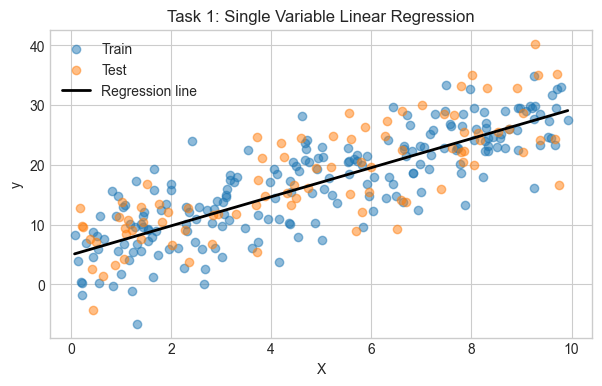

In [2]:
# Create a synthetic one-feature dataset
rng = np.random.default_rng(42)
X_single = rng.uniform(0, 10, size=(300, 1))
noise_single = rng.normal(0, 5, size=300)
y_single = 5 + 2.5 * X_single[:, 0] + noise_single

# 70/30 train-test split
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single, y_single, test_size=0.3, random_state=42
)

# Train linear regression
single_lr = LinearRegression()
single_lr.fit(X_train_single, y_train_single)

y_pred_single = single_lr.predict(X_test_single)
single_mse = mean_squared_error(y_test_single, y_pred_single)
all_mse_results['task1_single_linear_mse'] = single_mse

print(f'Task 1 MSE: {single_mse:.4f}')
print(f'Intercept: {single_lr.intercept_:.4f}')
print(f'Coefficient: {single_lr.coef_[0]:.4f}')

# Visualization
x_plot = np.linspace(X_single.min(), X_single.max(), 200).reshape(-1, 1)
y_plot = single_lr.predict(x_plot)

plt.figure(figsize=(7, 4))
plt.scatter(X_train_single, y_train_single, alpha=0.5, label='Train')
plt.scatter(X_test_single, y_test_single, alpha=0.5, label='Test')
plt.plot(x_plot, y_plot, color='black', linewidth=2, label='Regression line')
plt.title('Task 1: Single Variable Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Task 2: Synthetic Dataset (Multiple Variables) + Linear Regression + MSE

In [3]:
# Create a synthetic multi-feature dataset
X_multi, y_multi, true_coef = make_regression(
    n_samples=600,
    n_features=5,
    n_informative=5,
    noise=20,
    coef=True,
    random_state=42
)

# 70/30 train-test split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42
)

# Train linear regression
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)

y_pred_multi = multi_lr.predict(X_test_multi)
multi_mse = mean_squared_error(y_test_multi, y_pred_multi)
all_mse_results['task2_multi_linear_mse'] = multi_mse

print(f'Task 2 MSE: {multi_mse:.4f}')
print('Learned coefficients:', np.round(multi_lr.coef_, 3))
print('True coefficients:   ', np.round(true_coef, 3))


Task 2 MSE: 406.5196
Learned coefficients: [43.362 26.466 97.399 98.801 81.466]
True coefficients:    [43.123 25.967 96.972 98.357 81.874]


## Task 3: Manual Batch GD and Manual SGD on Task 2 Dataset

Batch GD Test MSE: 406.5196
SGD Test MSE:      407.8385


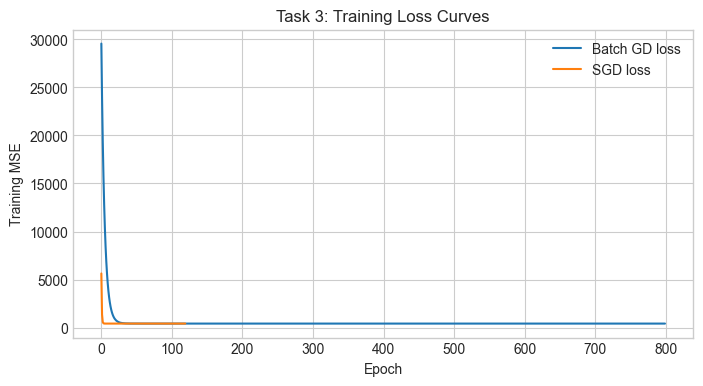

In [4]:
# Standardize features for stable gradient-based optimization
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

# Add bias column to represent intercept in weight vector
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train_gd = add_bias(X_train_multi_scaled)
X_test_gd = add_bias(X_test_multi_scaled)

def mse_loss(X, y, w):
    return np.mean((X @ w - y) ** 2)

def batch_gradient_descent(X, y, lr=0.05, epochs=800):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    losses = []

    for _ in range(epochs):
        error = X @ w - y
        gradient = (2 / n_samples) * (X.T @ error)
        w -= lr * gradient
        losses.append(np.mean(error ** 2))

    return w, losses

def stochastic_gradient_descent(X, y, lr=0.001, epochs=120):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    losses = []
    rng = np.random.default_rng(42)

    for _ in range(epochs):
        for idx in rng.permutation(n_samples):
            xi = X[idx]
            yi = y[idx]
            error_i = xi @ w - yi
            gradient_i = 2 * xi * error_i
            w -= lr * gradient_i

        losses.append(np.mean((X @ w - y) ** 2))

    return w, losses

w_gd, gd_losses = batch_gradient_descent(X_train_gd, y_train_multi)
w_sgd, sgd_losses = stochastic_gradient_descent(X_train_gd, y_train_multi)

y_pred_gd = X_test_gd @ w_gd
y_pred_sgd = X_test_gd @ w_sgd

gd_test_mse = mean_squared_error(y_test_multi, y_pred_gd)
sgd_test_mse = mean_squared_error(y_test_multi, y_pred_sgd)

all_mse_results['task3_manual_batch_gd_mse'] = gd_test_mse
all_mse_results['task3_manual_sgd_mse'] = sgd_test_mse

print(f'Batch GD Test MSE: {gd_test_mse:.4f}')
print(f'SGD Test MSE:      {sgd_test_mse:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(gd_losses, label='Batch GD loss')
plt.plot(sgd_losses, label='SGD loss')
plt.title('Task 3: Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.legend()
plt.show()


## Task 4: Linear Regression vs Lasso vs Ridge on Diabetes Dataset (Library)

In [5]:
# Load diabetes dataset from sklearn library (equivalent of library-provided Diabetes.csv)
diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data
y_diabetes = diabetes.target

X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_diabetes, y_diabetes, test_size=0.3, random_state=42
)

models_dia = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Lasso(alpha=0.1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1, max_iter=20000, random_state=42))
    ]),
    'Ridge(alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ])
}

dia_results = []
for model_name, model in models_dia.items():
    model.fit(X_train_dia, y_train_dia)
    preds = model.predict(X_test_dia)
    mse = mean_squared_error(y_test_dia, preds)
    dia_results.append((model_name, mse))
    all_mse_results[f'task4_diabetes_{model_name}_mse'] = mse

df_dia_results = pd.DataFrame(dia_results, columns=['Model', 'MSE']).sort_values('MSE')
print(df_dia_results.to_string(index=False))


           Model         MSE
Lasso(alpha=0.1) 2817.087638
Ridge(alpha=1.0) 2819.982017
LinearRegression 2821.750981


## Task 5: Linear Regression vs Lasso vs Ridge on `boston.csv`

In [6]:
# Resolve boston.csv robustly for both notebook-local and workspace-root execution
boston_candidates = [
    Path('boston.csv'),
    Path('ML_Lab_DJ/Lab_1/boston.csv')
]

boston_path = None
for candidate in boston_candidates:
    if candidate.exists():
        boston_path = candidate
        break

if boston_path is None:
    raise FileNotFoundError('Could not locate boston.csv in expected paths.')

boston_df = pd.read_csv(boston_path)

# Use MEDV as target, all other columns as features
X_boston = boston_df.drop(columns=['MEDV'])
y_boston = boston_df['MEDV']

X_train_bos, X_test_bos, y_train_bos, y_test_bos = train_test_split(
    X_boston, y_boston, test_size=0.3, random_state=42
)

models_boston = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Lasso(alpha=0.1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1, max_iter=20000, random_state=42))
    ]),
    'Ridge(alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ])
}

boston_results = []
for model_name, model in models_boston.items():
    model.fit(X_train_bos, y_train_bos)
    preds = model.predict(X_test_bos)
    mse = mean_squared_error(y_test_bos, preds)
    boston_results.append((model_name, mse))
    all_mse_results[f'task5_boston_{model_name}_mse'] = mse

df_boston_results = pd.DataFrame(boston_results, columns=['Model', 'MSE']).sort_values('MSE')
print(df_boston_results.to_string(index=False))


           Model       MSE
LinearRegression 21.517444
Ridge(alpha=1.0) 21.548654
Lasso(alpha=0.1) 22.788459


## Final Cross-Check

In [7]:
# Cross-check that all assignments ran and produced valid MSE values
expected_result_count = 10

assert len(all_mse_results) == expected_result_count, (
    f'Expected {expected_result_count} MSE entries, found {len(all_mse_results)}.'
)

for key, value in all_mse_results.items():
    assert np.isfinite(value), f'MSE is not finite for {key}: {value}'
    assert value >= 0, f'MSE must be non-negative for {key}: {value}'

# Sanity check: optimization losses should reduce over time
assert gd_losses[-1] < gd_losses[0], 'Batch GD loss did not decrease.'
assert min(sgd_losses) < sgd_losses[0], 'SGD loss never improved from its initial value.'

summary = pd.Series(all_mse_results).sort_values()
print('All cross-checks passed.')
print()
print('MSE summary (lower is better):')
print(summary.to_string())


All cross-checks passed.

MSE summary (lower is better):
task5_boston_LinearRegression_mse        21.517444
task5_boston_Ridge(alpha=1.0)_mse        21.548654
task5_boston_Lasso(alpha=0.1)_mse        22.788459
task1_single_linear_mse                  30.494520
task3_manual_batch_gd_mse               406.519598
task2_multi_linear_mse                  406.519598
task3_manual_sgd_mse                    407.838476
task4_diabetes_Lasso(alpha=0.1)_mse    2817.087638
task4_diabetes_Ridge(alpha=1.0)_mse    2819.982017
task4_diabetes_LinearRegression_mse    2821.750981
